/tmp/ipykernel_2383/2249666564.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  species_mean = df.groupby('species').mean()


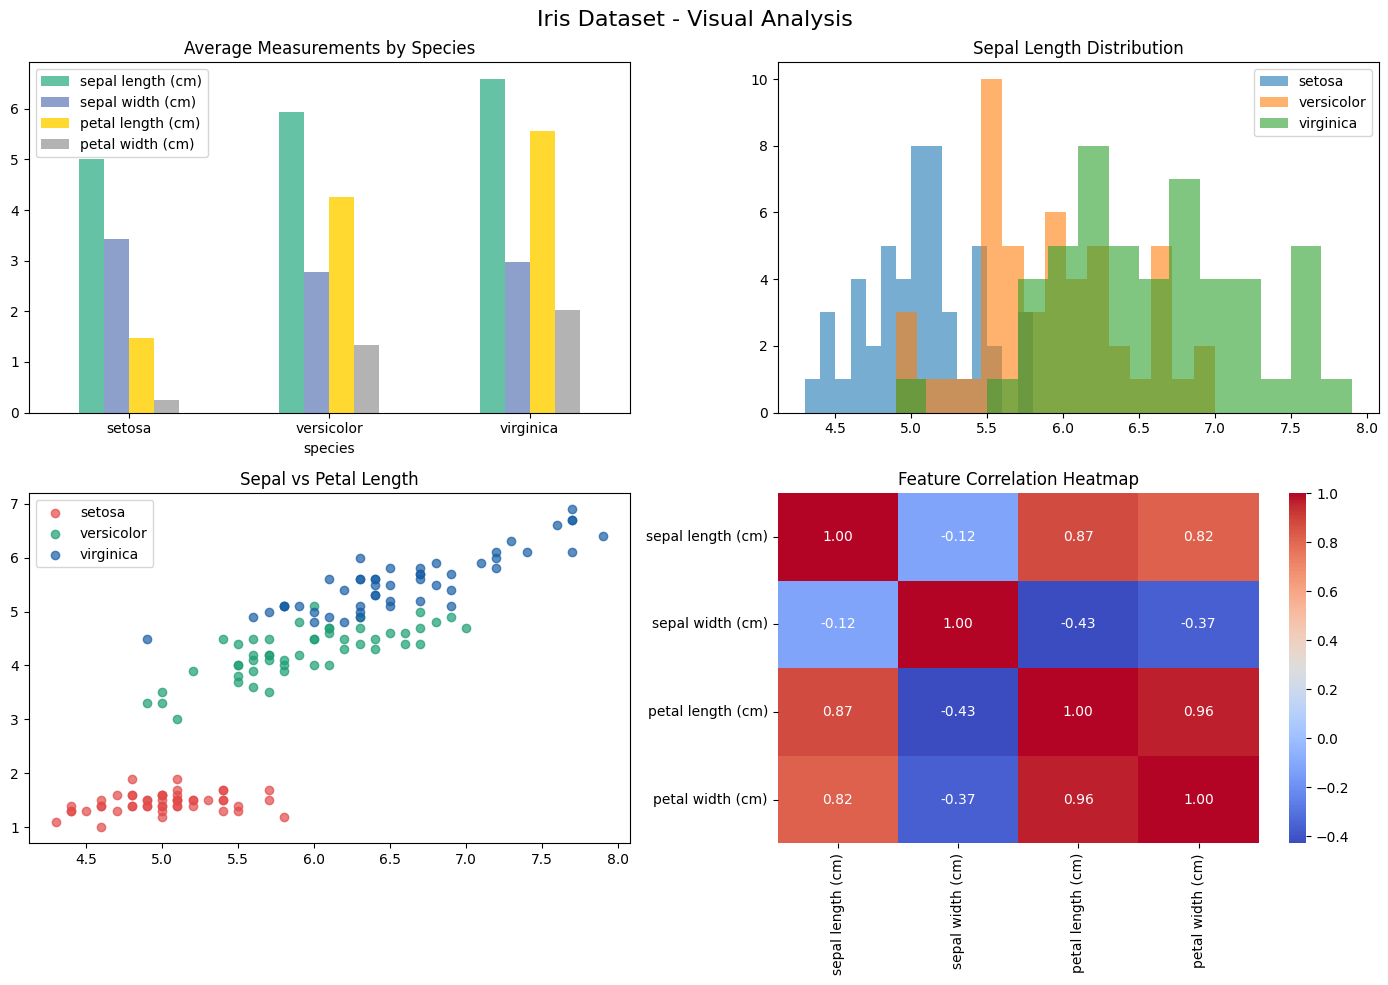

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Iris Dataset - Visual Analysis', fontsize=16)

# 1. Bar Chart
species_mean = df.groupby('species').mean()
species_mean.plot(kind='bar', ax=axes[0,0], colormap='Set2', rot=0)
axes[0,0].set_title('Average Measurements by Species')

# 2. Histogram
for sp in df['species'].unique():
    axes[0,1].hist(df[df['species']==sp]['sepal length (cm)'], alpha=0.6, label=sp, bins=15)
axes[0,1].set_title('Sepal Length Distribution')
axes[0,1].legend()

# 3. Scatter Plot
colors = {'setosa':'#E24B4A','versicolor':'#1D9E75','virginica':'#185FA5'}
for sp, color in colors.items():
    subset = df[df['species']==sp]
    axes[1,0].scatter(subset['sepal length (cm)'], subset['petal length (cm)'], label=sp, color=color, alpha=0.7)
axes[1,0].set_title('Sepal vs Petal Length')
axes[1,0].legend()

# 4. Heatmap
corr = df.drop('species', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1,1], fmt='.2f')
axes[1,1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('iris_visualizations.png', dpi=150)
plt.show()